In [1]:
# Cell 1: Environment Setup and Data Ingestion for Resilient Algorithms
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Re-ingest and preprocess data (Consolidated from baseline phase)
# Using raw string (r"...") to handle Windows backslashes seamlessly
filepath = r"./dataset/GothamDataset2025/processed/iotsim-air-quality-1.csv"
df = pd.read_csv(filepath)

columns_to_drop = ['frame.time', 'eth.src', 'eth.dst', 'ip.src', 'ip.dst', 'frame.protocols', 'tcp.options', 'ip.checksum', 'tcp.checksum']
df_clean = df.drop(columns=columns_to_drop, errors='ignore').fillna(0)

def hex_to_int(val):
    try:
        if isinstance(val, str) and val.startswith('0x'): return int(val, 16)
        return float(val)
    except: return 0

df_clean['ip.flags'] = df_clean['ip.flags'].apply(hex_to_int)
df_clean['tcp.flags'] = df_clean['tcp.flags'].apply(hex_to_int)

# 2. Feature isolation and target encoding
X = df_clean.drop(columns=['label'])
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_clean['label'])
target_names = label_encoder.classes_

# 3. Data partitioning (Crucial: Split BEFORE applying SMOTE to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Status: Base environment loaded and data partitioned successfully.")
print(f"Original Training Set Shape: {X_train.shape}")

Status: Base environment loaded and data partitioned successfully.
Original Training Set Shape: (44041, 13)


In [2]:
# Cell 2: Algorithmic Resilience via Synthetic Minority Over-sampling (SMOTE)

print("Initiating SMOTE to balance the training distribution...")
# Initialize SMOTE. This will synthetically generate instances for all minority classes 
# until they match the size of the absolute majority class.
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Resampled Training Set Shape: {X_train_resampled.shape} (Synthetic data injected successfully)\n")

print("Training Resilient Model (Random Forest augmented with SMOTE)...")
# Leveraging all CPU cores (n_jobs=-1) to handle the significantly larger resampled dataset
rf_resilient = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_resilient.fit(X_train_resampled, y_train_resampled)

# Execute predictions on the UNTOUCHED testing set to ensure valid evaluation
y_pred_resilient = rf_resilient.predict(X_test)

print("\nResilient Model Evaluation (Classification Report post-SMOTE):")
print(classification_report(y_test, y_pred_resilient, target_names=target_names, zero_division=0))

Initiating SMOTE to balance the training distribution...
Resampled Training Set Shape: (98755, 13) (Synthetic data injected successfully)

Training Resilient Model (Random Forest augmented with SMOTE)...

Resilient Model Evaluation (Classification Report post-SMOTE):
                       precision    recall  f1-score   support

               Benign       1.00      1.00      1.00      1447
Ingress Tool Transfer       1.00      0.95      0.98        22
             TCP Scan       0.97      0.97      0.97      4938
   Telnet Brute Force       0.97      0.97      0.97      4433
              Unknown       0.99      1.00      1.00       171

             accuracy                           0.97     11011
            macro avg       0.99      0.98      0.98     11011
         weighted avg       0.97      0.97      0.97     11011



In [3]:
# Cell 3: Algorithmic Resilience via Cost-Sensitive Learning (Algorithm-level)

print("Training Resilient Model (Random Forest with Cost-Sensitive Learning)...")
# Crucial: We use the ORIGINAL imbalanced dataset (X_train, y_train), NOT the SMOTE version.
# class_weight='balanced' automatically adjusts weights inversely proportional to class frequencies.
# Misclassifying a minority instance (e.g., Ingress) will incur a massive penalty compared to a majority instance.
rf_cost_sensitive = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)
rf_cost_sensitive.fit(X_train, y_train)

# Execute predictions on the UNTOUCHED testing set
y_pred_cost_sensitive = rf_cost_sensitive.predict(X_test)

print("\nResilient Model Evaluation (Classification Report post-Cost-Sensitive Learning):")
print(classification_report(y_test, y_pred_cost_sensitive, target_names=target_names, zero_division=0))

Training Resilient Model (Random Forest with Cost-Sensitive Learning)...

Resilient Model Evaluation (Classification Report post-Cost-Sensitive Learning):
                       precision    recall  f1-score   support

               Benign       1.00      1.00      1.00      1447
Ingress Tool Transfer       1.00      0.95      0.98        22
             TCP Scan       0.97      0.97      0.97      4938
   Telnet Brute Force       0.97      0.96      0.97      4433
              Unknown       0.99      1.00      1.00       171

             accuracy                           0.97     11011
            macro avg       0.99      0.98      0.98     11011
         weighted avg       0.97      0.97      0.97     11011



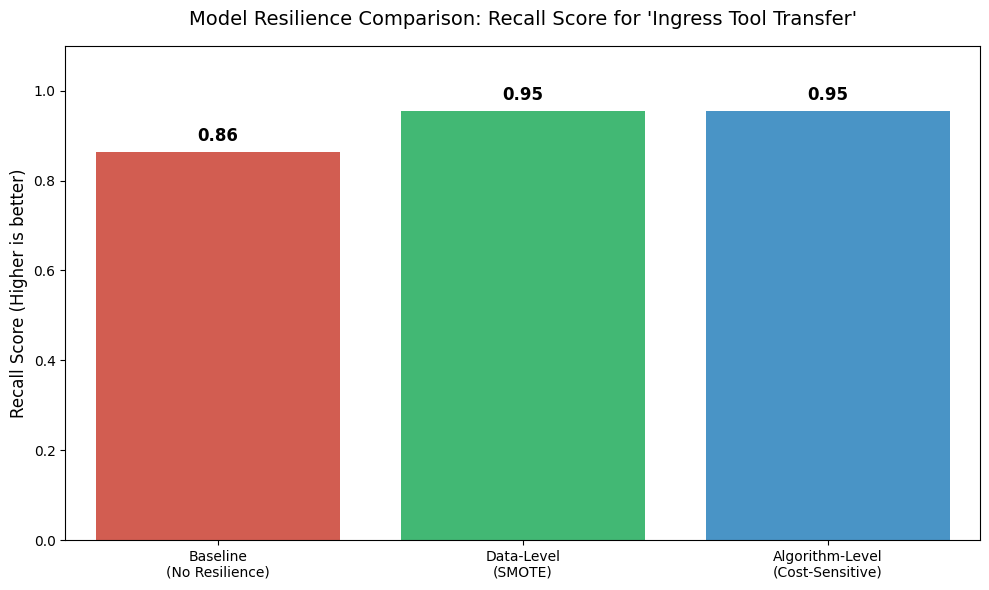

In [4]:
# Cell 4: Visualizing Algorithmic Resilience - Performance Comparison on Minority Class
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score
import numpy as np

# Re-run a quick baseline prediction for complete comparison within this notebook
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)
y_pred_baseline = rf_baseline.predict(X_test)

# Find the exact encoded index for 'Ingress Tool Transfer'
minority_class_name = 'Ingress Tool Transfer'
minority_class_index = np.where(target_names == minority_class_name)[0][0]

# Extract Recall scores specifically for the minority class
recall_baseline = recall_score(y_test, y_pred_baseline, labels=[minority_class_index], average=None)[0]
recall_smote = recall_score(y_test, y_pred_resilient, labels=[minority_class_index], average=None)[0]
recall_cost = recall_score(y_test, y_pred_cost_sensitive, labels=[minority_class_index], average=None)[0]

# Prepare data for visualization
models = ['Baseline\n(No Resilience)', 'Data-Level\n(SMOTE)', 'Algorithm-Level\n(Cost-Sensitive)']
recalls = [recall_baseline, recall_smote, recall_cost]

# Generate the comparison bar chart
plt.figure(figsize=(10, 6))
# Colors: Red for bad/baseline, Green/Blue for improved models
colors = ['#e74c3c', '#2ecc71', '#3498db'] 
ax = sns.barplot(x=models, y=recalls, palette=colors, hue=models, legend=False)

plt.title(f"Model Resilience Comparison: Recall Score for '{minority_class_name}'", fontsize=14, pad=15)
plt.ylabel("Recall Score (Higher is better)", fontsize=12)
plt.ylim(0, 1.1) # Set y-axis slightly above 1 for label clearance

# Annotate bars with the exact scores
for i, p in enumerate(ax.patches):
    ax.annotate(f'{recalls[i]:.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=12, color='black', fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()